#DeepContext_RAG (pet-проект)


## 1) Формулировка задачи: описание контекста и цели проекта


Я делала RAG-чат-ассистент для работы с внутренней документацией.

Самое важное - использовать чистую LLM без источников в таком контексте нельзя, потому что она будет галлюцинировать и выдавать правдоподобные, но неверные ответы. Для технической документации это критично.

Поэтому я построила классический RAG-пайплайн, в котором источник знаний отделён от модели, а генерация ответа возможна только на основе найденных фрагментов документации. Структура: предобработка и разбиение документов → построение эмбеддингов → хранение в векторном хранилище → семантический поиск релевантных фрагментов → передача их в LLM для генерации ответа строго на основе источников.
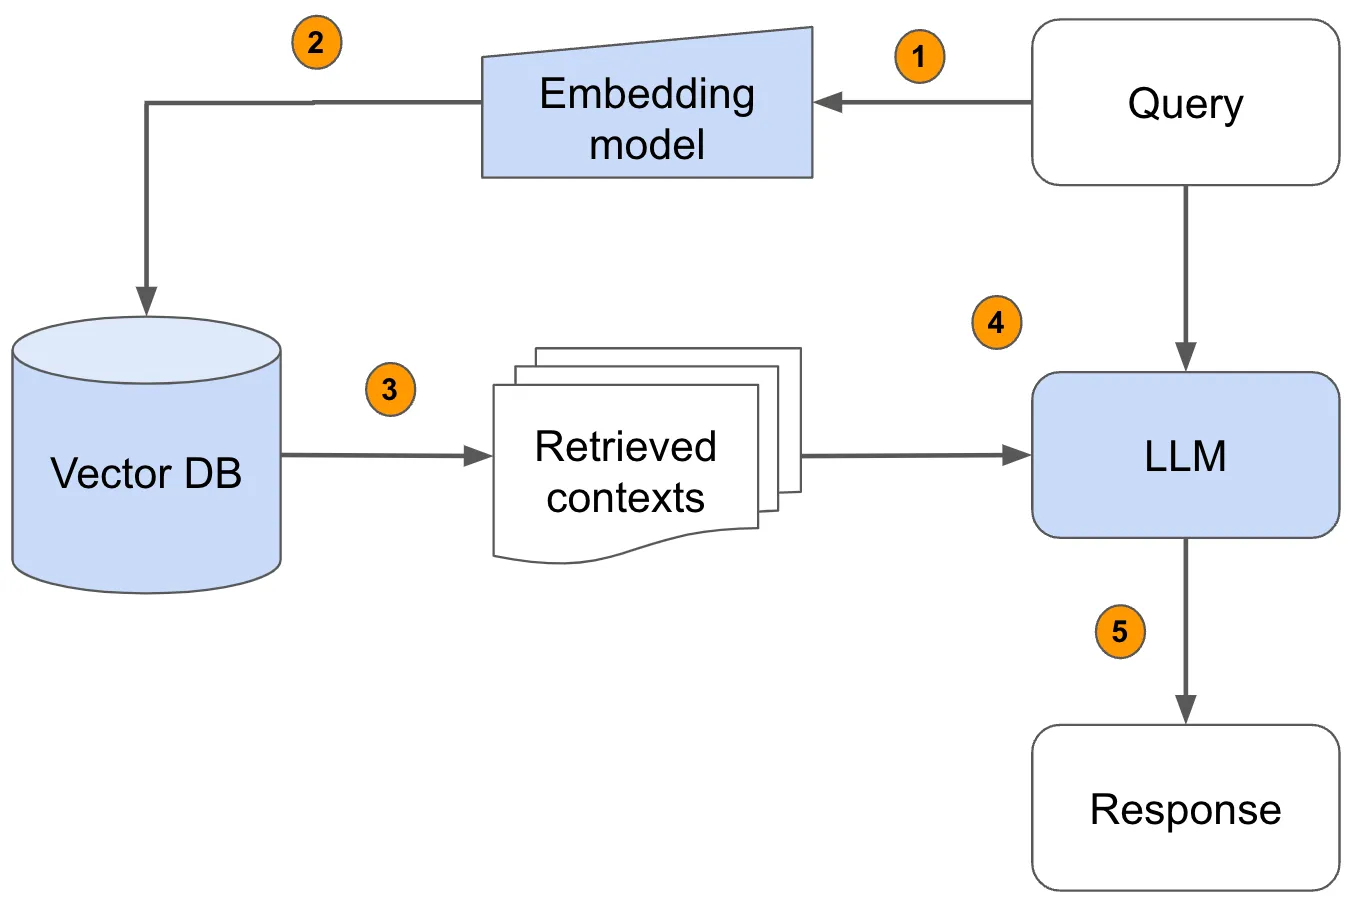




## 2) Работа с ограничениями: учёт ограничений — технические, временные, ресурсные — и как они влияли на принятые решения


#### Технические ограничения


**Ограничение:** невозможно передавать в модель целые документы или большие разделы без потери эффективности и роста стоимости. (ограниченный контекст LLM)

**Решение:** документы разбиваются на смысловые чанки фиксированного размера с overlap, что позволяет балансировать между полнотой контекста и качеством retrieval.


**Ограничение:** качество ответа зависит от retrieval, а не от LLM

**Решение:** фокус был сделан не на выборе LLM, а на настройке retrieval: подбор embedding-модели, оптимизация chunking, параметров поиска и фильтрации релевантных фрагментов.

#### Временные ограничения

**Ограничение:** проект выполнялся в рамках курса *"Разработка IT-проектов"* в Москвосвком Авиационном Институте, поэтому имел жесткий дедлайн

**Решение:** так как темы проектов мы должны были выбирать сами, то я выбрала классическую RAG-архитектуру, использовала готовые embedding-модели и отказалась от дообучения LLM.

#### Ресурсные ограничения

**Ограничение:** проект разрабатывался только одним человеком

**Решение:** минималистичная архитектура без избыточных сервисов, упор на простоту, воспроизводимость и читаемость кода.

## 3) Анализ альтернатив и обоснование выбора


#### Выбор векторного хранилища

**1) Хранение эмбеддингов в памяти (in-memory)**

**Плюсы:** подходит для прототипов и небольших датасетов, минимальная инфраструктура, простая реализация.

**Минусы:** хранение данных ограничено объемом оперативной памяти и не поддерживает сохранение данных между перезапусками, поэтому плохо подходит для роста объема документов и стабильной работы RAG-системы

**Вывод:** вариант допустим только для экспериментов, но не подходит для полноценного RAG-пайплайна.

**2) Elasticsearch с векторным поиском**

**Плюсы:** хорошо подходит для текстового поиска, фильтрации по метаданным и гибридных сценариев (лексический поиск + семантический поиск).

**Минусы:** производительность и качество поиска уступают специализированным векторным базам, особенно при росте объёма данных

**Вывод:** подходит для гибридного поиска, но не является оптимальным решением для чистого RAG, так как векторный поиск - не основной сценарий, а дополнение.

**3) Специализированное векторное хранилище (Milvus)**

**Плюсы:** оптимизировано именно под векторный поиск, хорошо масштабируется и эффективно работает с большими коллекциями эмбеддингов. Широко используется в RAG-сценариях.

**Минусы:** Более сложная инфраструктура, требует отдельного сервиса и настройки.

**Вывод:** Milvus оказался наиболее подходящим вариантом для RAG-задачи, где качество и стабильность семантического поиска критичны.



#### Выбор модели embeddings

**Сравнение популярных embedding-моделей**

| Модель                         | Rank (Borda) | Mean (Task) | Retrieval |       STS | Memory (MB) | Params (B) |      Dim | Max tokens | Комментарий                                         |
| ------------------------------ | -----------: | ----------: | --------: | --------: | ----------: | ---------: | -------: | ---------: | --------------------------------------------------- |
| Qwen3-Embedding-0.6B           |            8 |       64.34 |     64.65 |     76.17 |        1136 |      0.596 |     1024 |      32768 | Сильная мультиязычная модель, но без фокуса на RU   |
| multilingual-e5-large-instruct |           11 |       63.22 |     57.12 |     76.81 |        1068 |      0.560 |     1024 |        514 | Универсальный baseline для разных языков            |
| embeddinggemma-300m            |           12 |       61.15 |     62.49 |     74.73 |        1155 |      0.308 |      768 |       2048 | Компактная, но не RU-специализированная             |
| text-embedding-3-large         |           23 |         NaN |     59.32 |     71.68 |         NaN |        NaN |     3072 |       8191 | Удобный API-embedding, чёрный ящик                  |
| jina-embeddings-v3             |           29 |       58.37 |     55.76 |     77.13 |        1092 |      0.572 |     1024 |       8194 | Хорошие STS, слабее в retrieval                     |
| bge-m3                         |           30 |       59.56 |     54.60 |     74.12 |        2167 |      0.568 |     1024 |       8194 | Популярная, но тяжёлая и универсальная              |
| **ru-en-RoSBERTa**             |      **124** |   **41.57** | **32.68** | **52.97** |    **1540** |  **0.404** | **1024** |    **512** | **RU+EN модель, оптимальна для русскоязычного RAG** |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


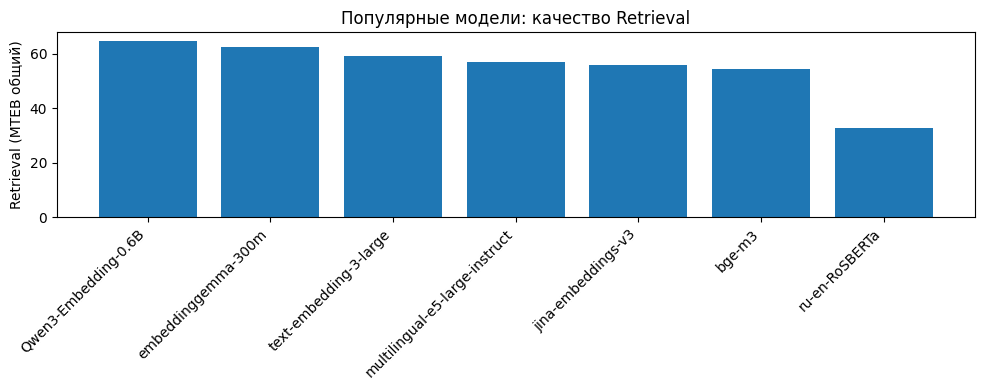

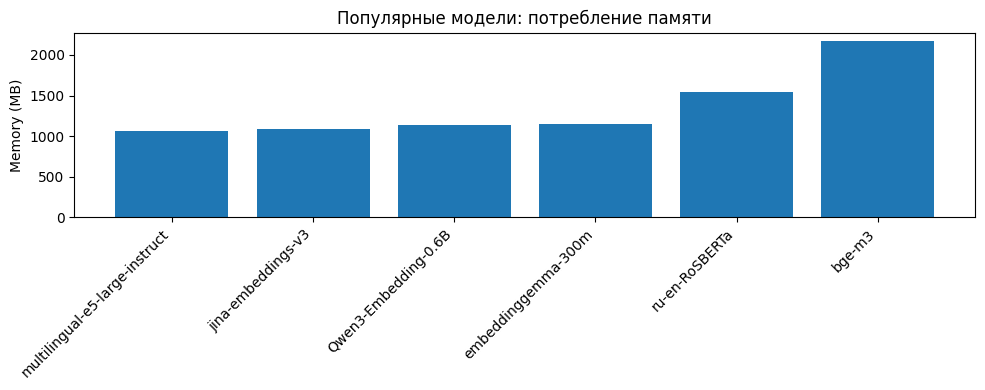

In [ ]:
popular = pd.DataFrame([
    {"model":"Qwen3-Embedding-0.6B",           "retrieval":64.65, "memory_mb":1136, "params_b":0.596},
    {"model":"multilingual-e5-large-instruct", "retrieval":57.12, "memory_mb":1068, "params_b":0.560},
    {"model":"embeddinggemma-300m",            "retrieval":62.49, "memory_mb":1155, "params_b":0.308},
    {"model":"text-embedding-3-large",         "retrieval":59.32, "memory_mb":np.nan, "params_b":np.nan},
    {"model":"jina-embeddings-v3",             "retrieval":55.76, "memory_mb":1092, "params_b":0.572},
    {"model":"bge-m3",                         "retrieval":54.60, "memory_mb":2167, "params_b":0.568},
    {"model":"ru-en-RoSBERTa",                 "retrieval":32.68, "memory_mb":1540, "params_b":0.404},
])

df = popular.sort_values("retrieval", ascending=False)
plt.figure(figsize=(10,4))
plt.bar(df["model"], df["retrieval"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Retrieval (MTEB общий)")
plt.title("Популярные модели: качество Retrieval")
plt.tight_layout()
plt.show()

df = popular.dropna(subset=["memory_mb"]).sort_values("memory_mb", ascending=True)
plt.figure(figsize=(10,4))
plt.bar(df["model"], df["memory_mb"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Memory (MB)")
plt.title("Популярные модели: потребление памяти")
plt.tight_layout()
plt.show()


**Сравнение русскоязычных embedding-моделей**

| Модель                                | Ориентация   | Качество на RU (MTEB)                   | Размер / ресурсы | Комментарий                                      |
| ------------------------------------- | ------------ | --------------------------------------- | ---------------- | ------------------------------------------------ |
| **ai-forever/ru-en-RoSBERTa**         | RU + EN      | **Топ-1 / Топ-2 на rus-Cyrl Retrieval** | ~400M параметров | Лучший баланс качества и веса для русского       |
| deepvk/USER-base                      | RU           | Очень высокое                           | ~120M            | Быстрая и лёгкая, но слабее на сложной семантике |
| BAAI/bge-m3                           | Multilingual | Почти на уровне ru-en-RoSBERTa          | ~560M            | Универсальная, но не специализирована под RU     |
| DeepPavlov/rubert-base-cased-sentence | RU           | Хорошее                                 | ~180M            | Классическая RU-модель, уступает по retrieval    |
| cointegrated/LaBSE-en-ru              | RU + EN      | Среднее                                 | ~130M            | Старый baseline, заметно слабее в RAG            |
| sergeyzh/LaBSE-ru-turbo               | RU           | Среднее+                                | ~130M            | Оптимизированная версия LaBSE                    |
| multilingual-e5-large                 | Multilingual | Хорошее                                 | ~560M            | Сильна, но не RU-специализированная              |
| **e5-mistral-7b-instruct**            | Multilingual | Высокое                                 | **7B (!)**       | Непрактична для RAG из-за веса                   |


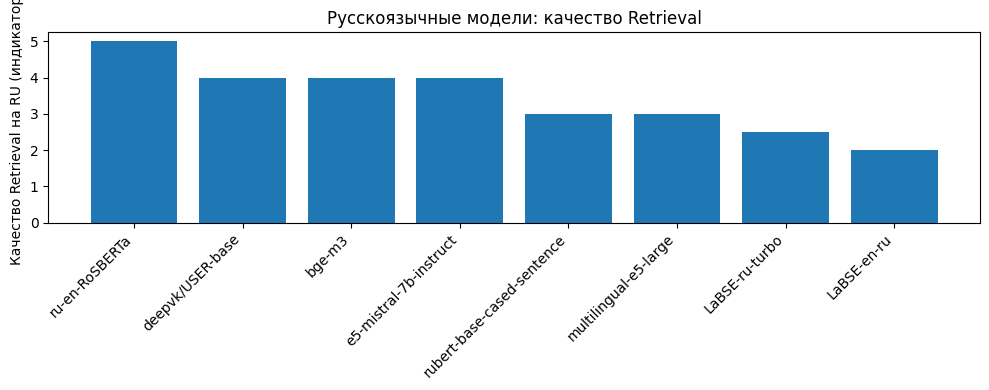

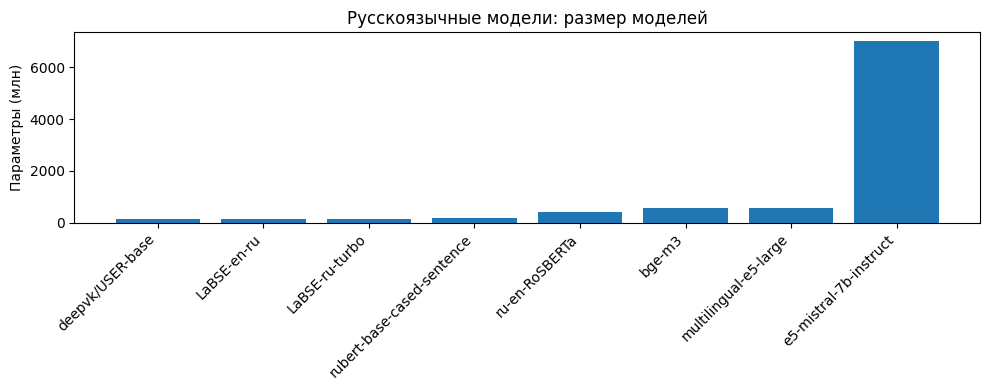

In [ ]:
ru_models = pd.DataFrame([
    {"model": "ru-en-RoSBERTa", "ru_quality": 5, "params_m": 400},
    {"model": "deepvk/USER-base", "ru_quality": 4, "params_m": 120},
    {"model": "bge-m3", "ru_quality": 4, "params_m": 560},
    {"model": "rubert-base-cased-sentence", "ru_quality": 3, "params_m": 180},
    {"model": "LaBSE-en-ru", "ru_quality": 2, "params_m": 130},
    {"model": "LaBSE-ru-turbo", "ru_quality": 2.5, "params_m": 130},
    {"model": "multilingual-e5-large", "ru_quality": 3, "params_m": 560},
    {"model": "e5-mistral-7b-instruct", "ru_quality": 4, "params_m": 7000},
])

df = ru_models.sort_values("ru_quality", ascending=False)

plt.figure(figsize=(10,4))
plt.bar(df["model"], df["ru_quality"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Качество Retrieval на RU (индикатор)")
plt.title("Русскоязычные модели: качество Retrieval")
plt.tight_layout()
plt.show()


df = ru_models.sort_values("params_m", ascending=True)

plt.figure(figsize=(10,4))
plt.bar(df["model"], df["params_m"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Параметры (млн)")
plt.title("Русскоязычные модели: размер моделей")
plt.tight_layout()
plt.show()



**Вывод:** ru-en-RoSBERTa является не самой сильной моделью в среднем по всем языкам, но одной из наиболее подходящих и эффективных моделей для русскоязычного RAG-сценария, что и определило её выбор в проекте.

**Выбор параметров для чанкования текста (chunk_size, overlap)**

Для разбиения документов была выбрана стратегия чанкинга с фиксированным размером фрагмента и overlap:
`chunk_size = 1200`, `overlap = 150`. Если бы я увеличила размер чанков, то в поиск попадало бы слишком много нерелевантного текста и ухудшало фокус LLM. При уменьшении чанков смысловая ценность начала бы теряться, и модель была бы вынуждена восстанавливать контекст из разрозненных частей.

**Вывод:** `chunk_size = 1200` и `overlap = 150` оказались идеальным вариантом, сохраняют смысл текста и при этом не перегружают retrieval

**Выбор параметра top-k**

Были протестированы разные значения top-k. Большие значения увеличивали шум в контексте, меньшие — приводили к потере информации.

**Вывод:** `top_k = 4` оказался оптимальным значением, обеспечивающим достаточный контекст без перегрузки LLM.

## 4) Анализ неудачных решений, выявление ошибок и формулировка выводов

**1) Использование слишком крупных чанков**

На раннем этапе я использовала слишком крупные чанки, рассчитывая сохранить больше контекста. На практике это приводило к менее точным ответам, так как в LLM попадало много нерелевантной информации.

**Вывод:** после уменьшения размера чанков и добавления overlap качество retrieval и итоговых ответов заметно улучшилось.

**2) Промптинг LLM**

На раннем этапе проекта использовался недостаточно строгий промпт для LLM. Модель не была жёстко ограничена рамками retrieved-контекста и могла опираться на собственные вероятностные знания.

Старый промпт: "*Отвечай ТОЛЬКО по контексту. Если ответа нет — так и скажи.*"

Новый промпт: "*Ты — ассистент RAG-системы. Отвечай только на основе переданного контекста. Если информации недостаточно, честно скажи об этом. Не придумывай факты и не добавляй сведения, которых нет в контексте. Если фрагменты противоречат друг другу, укажи на это. Отвечай по-русски, кратко, структурированно и логично.*"

**Вывод:** Я поняла, в RAG промптинг является важной частью архитектуры, напрямую влияющей на корректность и надёжность системы.

**3) Слишком большое значение top-k**

На ранних итерациях в LLM передавалось слишком много retrieved-фрагментов. Контекст становился зашумлённым, модель теряла фокус, ответы становились менее точными, несмотря на наличие нужной информации.

**Вывод:** Для RAG важнее качество контекста, чем его объём. Ограничение top-k и фильтрация по similarity дают лучший результат.

## 5. Общий вывод и возможности развития

В проекте реализована базовая RAG-система для работы с текстовой документацией на основе семантического поиска и LLM.

В дальнейшем я бы хотела развить свою систему, например, добавить OCR для обработки изображений, чтобы можно было работать с фото и сканами документов, а также попробовать свой RAG в деле, использовать его как бота, который помогает с технической документацией на заводе НЛМК (отдел радиационных источников цехов электротехнических сталей)